In [13]:
import pandas as pd

df = pd.read_csv("retail_sales.csv")
df.rename(columns={'Weekly_Sales': 'Sales'}, inplace=True)

df.head()

,Store,Date,Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [14]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Sales         6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,0
Store,0
Date,0
Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [15]:
# df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [16]:
df = df.drop_duplicates()

In [17]:
df = df.sort_values('Date')

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

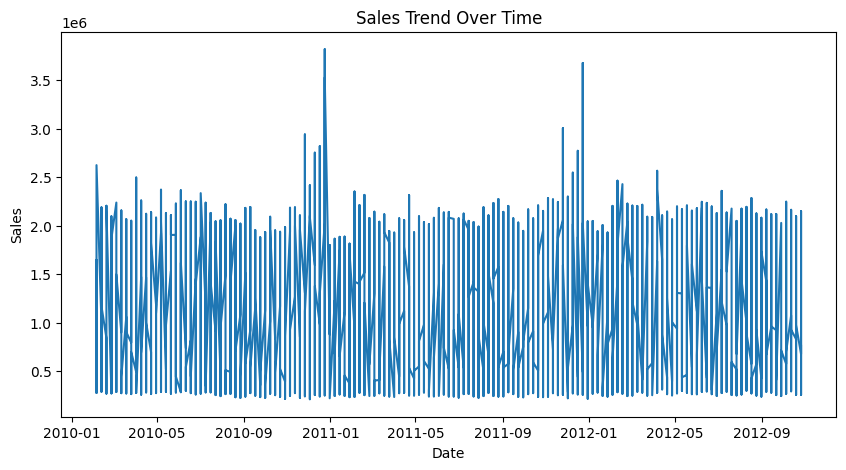

In [19]:
# Sales Trend Over Time
plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['Sales'])

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

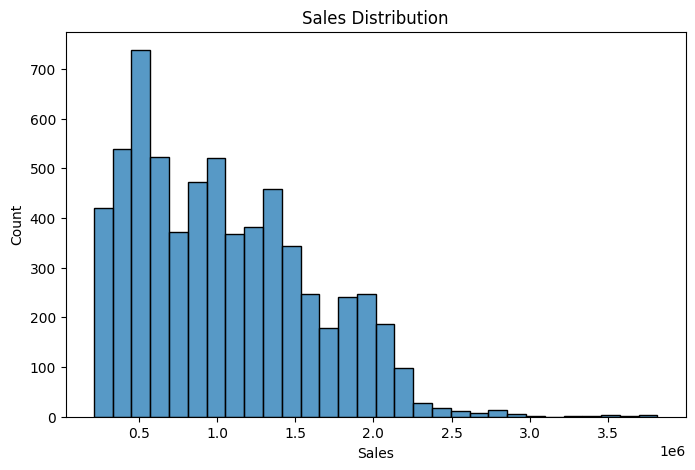

In [20]:
# Sales Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=30)

plt.title("Sales Distribution")

plt.show()

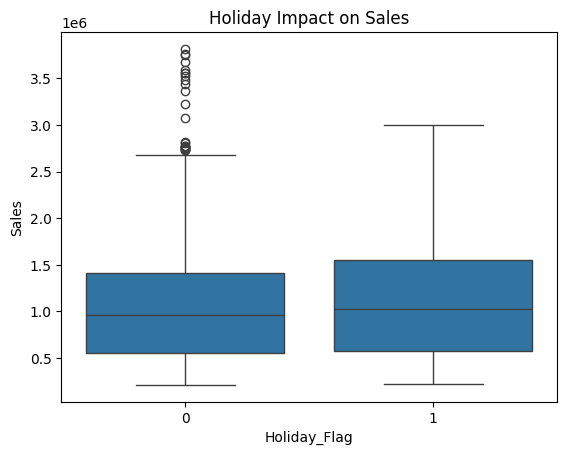

In [21]:
# Holiday vs Non-Holiday Sales
sns.boxplot(x='Holiday_Flag', y='Sales', data=df)

plt.title("Holiday Impact on Sales")

plt.show()

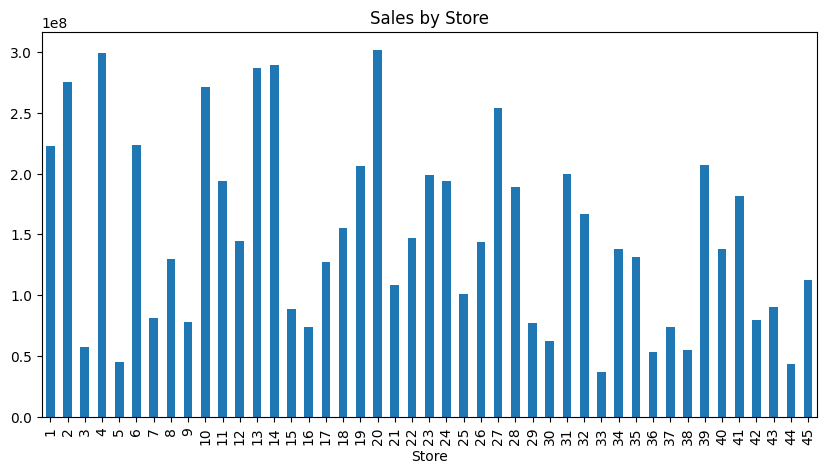

In [22]:
# Store Performance
store_sales = df.groupby("Store")["Sales"].sum()

store_sales.plot(kind='bar', figsize=(10,5))

plt.title("Sales by Store")

plt.show()

In [23]:
from prophet import Prophet

ts = df[['Date','Sales']]

ts = ts.rename(columns={
    'Date':'ds',
    'Sales':'y'
})

In [24]:
model = Prophet()

model.fit(ts)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [25]:
future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

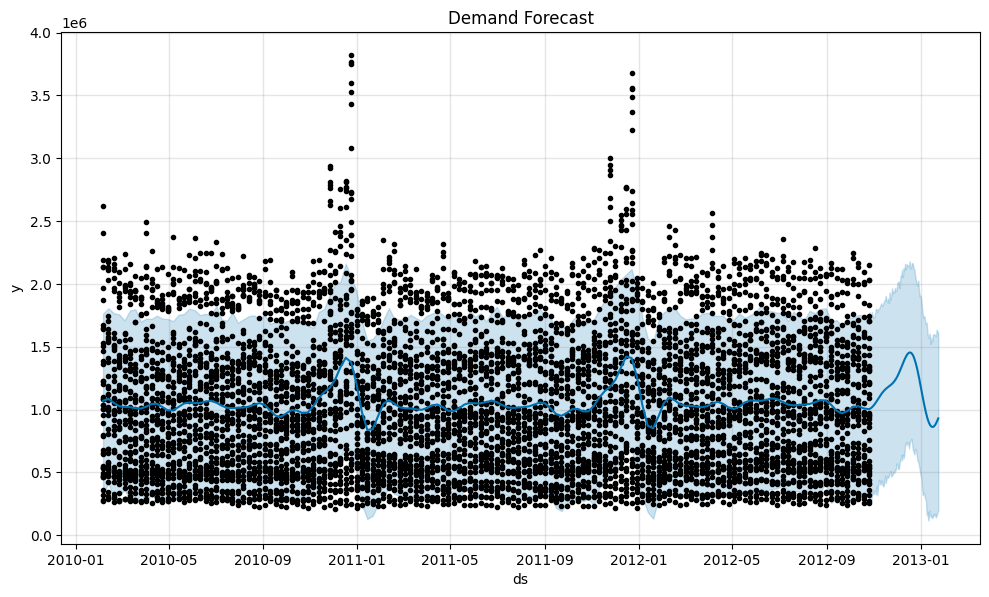

In [26]:
fig = model.plot(forecast)

plt.title("Demand Forecast")

plt.show()

In [27]:
plt.savefig("demand_forecast.png")

<Figure size 640x480 with 0 Axes>

In [28]:
import numpy as np

D = df['Sales'].sum()      # annual demand
S = 50                     # ordering cost
H = 5                      # holding cost

EOQ = np.sqrt((2 * D * S) / H)

print("Economic Order Quantity:", EOQ)

Economic Order Quantity: 367075.44148607925


In [29]:
# ROP = (average demand × lead time)
avg_daily_demand = df['Sales'].mean()

lead_time = 7   # days

reorder_point = avg_daily_demand * lead_time

print("Reorder Point:", reorder_point)

Reorder Point: 7328754.142932402


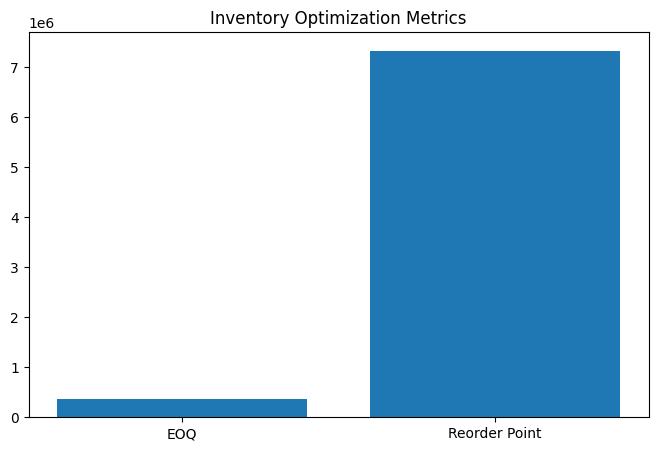

In [30]:
plt.figure(figsize=(8,5))

labels = ['EOQ','Reorder Point']
values = [EOQ, reorder_point]

plt.bar(labels, values)

plt.title("Inventory Optimization Metrics")

plt.show()

In [31]:
inventory_metrics = pd.DataFrame({
    "Metric":["EOQ","Reorder Point"],
    "Value":[EOQ,reorder_point]
})

inventory_metrics.to_csv("inventory_metrics.csv")